import necessary library

In [2]:
#basiclibs
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns
#modeling
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error   
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.svm import SVR
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV
from catboost import CatBoostRegressor
from xgboost import XGBRegressor

import warnings
warnings.filterwarnings('ignore')


In [4]:
df=pd.read_csv('data/Students.csv')

In [5]:
df['Total_score'] = df['math score'] + df['reading score'] + df['writing score']

In [6]:
X = df.drop(['Total_score'], axis=1)
y = df['Total_score']

In [7]:
numeric_cols = X.select_dtypes(exclude='object').columns
categorical_cols = X.select_dtypes(include='object').columns

In [16]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

numeric_transformer = StandardScaler()
categorical_transformer = OneHotEncoder()

In [17]:
preprocessor = ColumnTransformer(
    [
        ('onehotencoder', categorical_transformer, categorical_cols),
        ('standardscaler', numeric_transformer, numeric_cols)
    ]
)

In [18]:
X_transformed = preprocessor.fit_transform(X)

In [19]:
X_transformed.shape

(1000, 20)

In [20]:
x_train, x_test, y_train, y_test = train_test_split(X_transformed, y, test_size=0.2, random_state=42)
x_train.shape, x_test.shape, y_train.shape, y_test.shape

((800, 20), (200, 20), (800,), (200,))

In [ ]:
## create a function to train and evaluate models
/******def evaluate_model(model, x_train, y_train, x_test, y_test):
    model.fit(x_train, y_train)
    train_mse = mean_squared_error(y_train, model.predict(x_train))
    y_pred = model.predict(x_test)
    mse = mean_squared_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    return mse, r2, mae

model_list=[]
r2_list=[]
results = {}
for name, model in models.items():
    mse, r2, mae = train_and_evaluate_model(model, x_train, y_train, x_test, y_test)
    results[name] = {'MSE': mse, 'R2': r2, 'MAE': mae}*******/

In [26]:
def model_evaluation(true,predicted):
    mse = mean_squared_error(true, predicted)
    r2 = r2_score(true, predicted)
    mae = mean_absolute_error(true, predicted)
    rmse = np.sqrt(mse)
    return mse, r2, mae

In [33]:
models = {
    'Linear Regression': LinearRegression(),
    'Ridge Regression': Ridge(),
    'Lasso Regression': Lasso(), 
    'Decision Tree': DecisionTreeRegressor(random_state=42),
    'Random Forest': RandomForestRegressor(random_state=42),
    'KNN': KNeighborsRegressor(),
    'SVR': SVR(),
    'CatBoost': CatBoostRegressor(random_state=42, verbose=0),
    'XGBoost': XGBRegressor(random_state=42, verbosity=0)
}

model_list=[]
r2_list=[]

for i in range(len(list(models))):
    model=list(models.values())[i]
    model.fit(x_train, y_train)

    y_train_pred=model.predict(x_train) 
    y_test_pred=model.predict(x_test)

    mse_train, r2_train, mae_train=model_evaluation(y_train, y_train_pred)
    mse_test, r2_test, mae_test=model_evaluation(y_test, y_test_pred)


    print(list(models.keys())[i])
    model_list.append(list(models.keys())[i])

    print("Model performance for training set:")
    print(f"MSE: {mse_train:.4f}, R2: {r2_train:.4f}, MAE: {mae_train:.4f}")

    print("=================================")
    print("Model performance for test set:")
    print(f"MSE: {mse_test:.4f}, R2: {r2_test:.4f}, MAE: {mae_test:.4f}")

    print ("=================================")
    print("\n")
    r2_list.append(r2_test)

Linear Regression
Model performance for training set:
MSE: 0.0000, R2: 1.0000, MAE: 0.0000
Model performance for test set:
MSE: 0.0000, R2: 1.0000, MAE: 0.0000


Ridge Regression
Model performance for training set:
MSE: 0.0006, R2: 1.0000, MAE: 0.0195
Model performance for test set:
MSE: 0.0007, R2: 1.0000, MAE: 0.0201


Lasso Regression
Model performance for training set:
MSE: 1.1330, R2: 0.9994, MAE: 0.8505
Model performance for test set:
MSE: 1.2409, R2: 0.9994, MAE: 0.8764


Decision Tree
Model performance for training set:
MSE: 0.0000, R2: 1.0000, MAE: 0.0000
Model performance for test set:
MSE: 25.1150, R2: 0.9870, MAE: 3.3650


Random Forest
Model performance for training set:
MSE: 0.8071, R2: 0.9996, MAE: 0.5618
Model performance for test set:
MSE: 12.4542, R2: 0.9935, MAE: 1.5689


KNN
Model performance for training set:
MSE: 45.8584, R2: 0.9745, MAE: 5.3040
Model performance for test set:
MSE: 84.8588, R2: 0.9560, MAE: 6.8500


SVR
Model performance for training set:
MSE: 232

In [35]:
pd.DataFrame(list(zip(model_list, r2_list)), columns=['Model', 'R2']).sort_values(by='R2', ascending=False)

,Model,R2
0,Linear Regression,1.000000
1,Ridge Regression,1.000000
2,Lasso Regression,0.999357
8,XGBoost,0.994759
7,CatBoost,0.993721
4,Random Forest,0.993545
3,Decision Tree,0.986982
5,KNN,0.956016
6,SVR,0.761127


In [36]:
liner_model = LinearRegression(fit_intercept=True) 
liner_model=liner_model.fit(x_train, y_train)
y_pred=liner_model.predict(x_test)
score=r2_score(y_test, y_pred)*100
print(f"R2 Score: {score:.2f}%")

R2 Score: 100.00%


Text(0.5, 1.0, 'Actual vs Predicted Values')

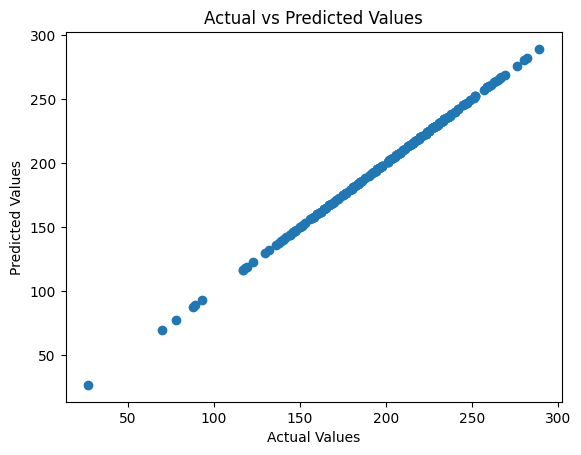

In [37]:
plt.scatter(y_test, y_pred)
plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')
plt.title('Actual vs Predicted Values')

In [24]:
model_list = list(results.keys())
r2_list = [metrics['R2'] for metrics in results.values()]

In [25]:
model_list


['Linear Regression',
 'Ridge Regression',
 'Lasso Regression',
 'Decision Tree',
 'Random Forest',
 'KNN',
 'SVR',
 'CatBoost',
 'XGBoost']